# Ejercicio 1 - Práctica 4

El dataset `iris.csv` contiene información sobre 150 flores de iris de tres especies diferentes: setosa, versicolor y virginica. Para cada flor, se midieron cuatro características: longitud y ancho del sépalo (la parte que rodea y protege el capullo de la flor) y longitud y ancho del pétalo (la parte coloreada de la flor).

1. Reproduzca el histograma mostrado en la siguiente figura para visualizar la distribución del ancho de sépalo (`sepal_width_cm`).

    ![Imagen 1](../img/69c9efcf57c57d639e853a1c40e50566f8cc6182bafd595274b89b814462542f.png)

    *Sugerencias:*

    - Configure previamente el theme de Seaborn utilizando `sns.set_theme(style='ticks')`.
    - El color de las barras debe ser darkred y deben tener borde negro.
    - El eje vertical debe expresarse en porcentaje.
    - Considere una partición en 12 intervalos de igual amplitud (0.2), cubriendo el rango desde 2.0 hasta 4.4. Puede lograrlo mediante el argumento `bins` y/o `binrange`.

2. Realice un boxplot múltiple que permita comparar la distribución del largo del pétalo de las flores entre las distintas especies. Comente brevemente lo observado. ¿Cuál de las especies presenta una mayor mediana del largo del pétalo?

3. Añada al gráfico anterior una representación de la media del largo del pétalo para cada especie. Para ello, puede utilizar `pointplot()` o una capa adicional con `stripplot()`/`scatterplot()` a partir de datos agregados.

    *Sugerencia:* para construir estos datos agregados, calcule previamente la media del largo del pétalo para cada especie, obteniendo un DataFrame reducido con una fila por especie.

    Una vez que tenga el gráfico construido, compare media y mediana en cada especie. ¿Qué indica esto sobre la simetría de las distribuciones?

4. Reproduzca el gráfico en paneles mostrado en la figura, en el que se presentan gráficos de violín para el ancho de sépalo (`sepal_width_cm`) y ancho de pétalo (`petal_width_cm`). Utilice `plt.subplots()` para crear los paneles y personalice cada gráfico en su respectivo eje. Superponga además los datos individuales mediante `stripplot()`.

    ---
    Sobre `plt.subplots()`

    La función `plt.subplots()` de Matplotlib crea una figura con una cuadrícula de subgráficos (elemento llamado `axes`), permitiendo organizar varios gráficos en una sola figura. El uso básico es el siguiente:

    `fig, axes = plt.subplots(nrows, ncols)` 
    Donde `nrows` y `ncols` especifican el número de filas y columnas de subgráficos. La función devuelve una figura (`fig`) y un array de ejes (`axes`). Cada subgráfico individual es un objeto de tipo Axes que se puede personalizar de manera independiente.
    
    ---

    *Sugerencias:*

    Utilice lightblue y darkorange como colores para el relleno de los gráficos de violín.

    Elimine los valores del eje vertical para mejorar la presentación.

    Ajuste el parámetro jitter en stripplot() para evitar la superposición excesiva de puntos.

    Analice los gráficos obtenidos. ¿Cuál de las siguientes opciones describe de una manera más precisa la forma de cada una de las distribuciones?

    - *Distribución simétrica*

    - *Distribución sesgada a la derecha*

    - *Distribución unimodal*

    - *Distribución bimodal*

    - *Distribución normal*

    - *Distribución sesgada a la izquierda*

    - Distribución uniforme

    ![](../img/a3939aff6c13fd9d544dce9a5f8584c5a78abcaf287e08c5d7c5ce6d1fb3e4a7.png)

5. Construya un gráfico que le permita analizar la relación general que existe entre las variables ancho y largo del pétalo. Realice un comentario acerca de lo observado y complemente el gráfico anterior informando una medida de la fuerza y la dirección de la asociación lineal entre ambas variables.

## Cargamos el data frame

In [ ]:
# Importamos los paquetes necesarios

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../datasets/iris.csv")
df.head()

,id,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               150 non-null    int64  
 1   sepal_length_cm  150 non-null    float64
 2   sepal_width_cm   150 non-null    float64
 3   petal_length_cm  150 non-null    float64
 4   petal_width_cm   150 non-null    float64
 5   species          150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [4]:
df.columns

Index(['id', 'sepal_length_cm', 'sepal_width_cm', 'petal_length_cm',
       'petal_width_cm', 'species'],
      dtype='str')

## Item 1

Reproduzca el histograma mostrado en la siguiente figura para visualizar la distribución del ancho de sépalo (`sepal_width_cm`).

*Sugerencias:*

- Configure previamente el theme de Seaborn utilizando `sns.set_theme(style='ticks')`.

- El color de las barras debe ser darkred y deben tener borde negro.

- El eje vertical debe expresarse en porcentaje.

- Considere una partición en 12 intervalos de igual amplitud (0.2), cubriendo el rango desde 2.0 hasta 4.4. Puede lograrlo mediante el argumento `bins` y/o `binrange`.

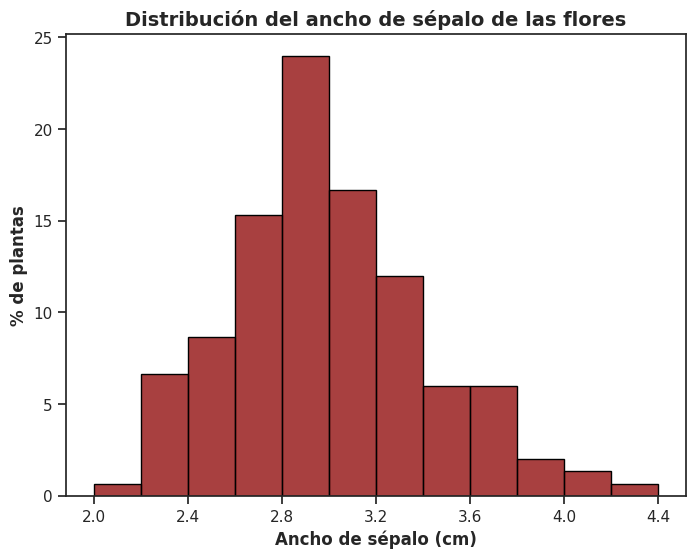

In [5]:
# Graficamos el histográma

plt.figure(figsize = (8,6))
sns.set_theme(style='ticks')

sns.histplot(x = 'sepal_width_cm', edgecolor = 'black', color = "darkred", data = df, 
                stat = "percent", bins = np.arange(2, 4.4, 0.2))
plt.xlabel('Ancho de sépalo (cm)', fontweight = 'bold')
plt.ylabel('% de plantas', fontweight = 'bold')
plt.title("Distribución del ancho de sépalo de las flores", fontsize = 14, fontweight = 'bold')
plt.xticks(np.arange(2,4.5,0.4))
plt.show()

## Item 2

Realice un boxplot múltiple que permita comparar la distribución del largo del pétalo de las flores entre las distintas especies. Comente brevemente lo observado. ¿Cuál de las especies presenta una mayor mediana del largo del pétalo?

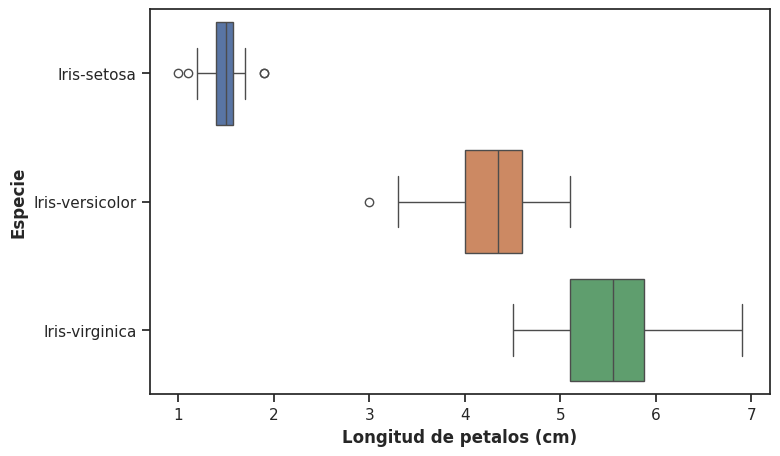

In [6]:
orden = (df.groupby('species')['petal_length_cm']
            .median().sort_values().index)
palette = sns.color_palette('viridis', 3)


plt.figure(figsize = (8, 5))

sns.boxplot(x = 'petal_length_cm', y = 'species',
            hue = 'species', order = orden, data = df)
plt.xlabel('Longitud de petalos (cm)', fontweight = 'bold')
plt.ylabel('Especie', fontweight = 'bold')
plt.show()

Comentar...

## Item 3

Añada al gráfico anterior una representación de la media del largo del pétalo para cada especie. Para ello, puede utilizar `pointplot()` o una capa adicional con `stripplot()`/`scatterplot()` a partir de datos agregados.

*Sugerencia:* para construir estos datos agregados, calcule previamente la media del largo del pétalo para cada especie, obteniendo un DataFrame reducido con una fila por especie.

Una vez que tenga el gráfico construido, compare media y mediana en cada especie. ¿Qué indica esto sobre la simetría de las distribuciones?



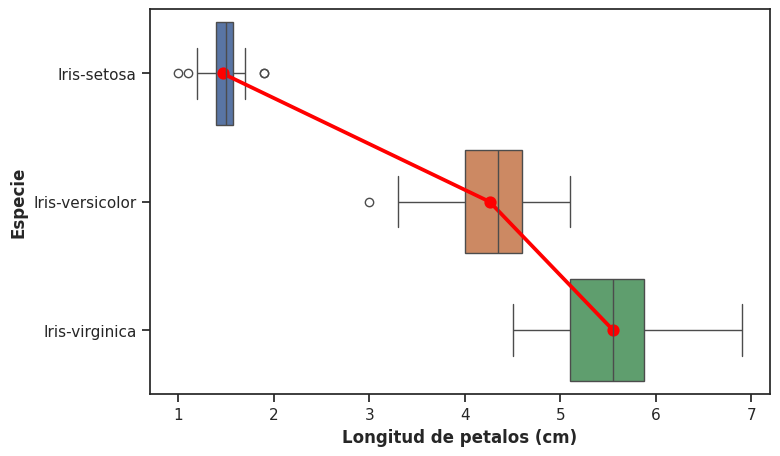

In [7]:
medias = df.groupby('species')['petal_length_cm'].mean().sort_values().to_frame(name = "media_petal_length_cm")
plt.figure(figsize = (8, 5))

sns.boxplot(x = 'petal_length_cm', y = 'species',
            hue = 'species', order = orden, data = df)
plt.xlabel('Longitud de petalos (cm)', fontweight = 'bold')
plt.ylabel('Especie', fontweight = 'bold')

sns.pointplot(data = medias, x = 'media_petal_length_cm', y = "species", color = "red")
plt.show()

Conclusiones...

# Item 4

Reproduzca el gráfico en paneles mostrado en la figura, en el que se presentan gráficos de violín para el ancho de sépalo (`sepal_width_cm`) y ancho de pétalo (`petal_width_cm`). Utilice `plt.subplots()` para crear los paneles y personalice cada gráfico en su respectivo eje. Superponga además los datos individuales mediante `stripplot()`.

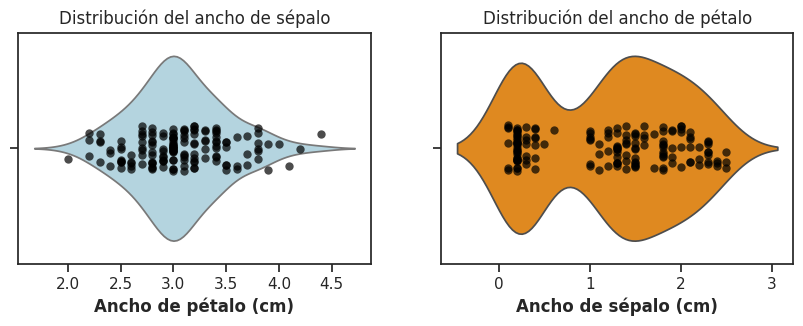

In [8]:

fig, axs = plt.subplots(1,2, figsize=(10, 3))

sns.violinplot(x = 'sepal_width_cm', color = "lightblue", inner = None, data = df, ax = axs[0])
sns.stripplot(x = 'sepal_width_cm',  data = df, color = 'black', size = 6, alpha = 0.7, jitter = True,  ax = axs[0])
axs[0].set_xlabel('Ancho de pétalo (cm)', fontweight = 'bold')
axs[0].set_title("Distribución del ancho de sépalo")

sns.violinplot(x = 'petal_width_cm', color = "darkorange", inner = None, data = df, ax = axs[1])
sns.stripplot(x = 'petal_width_cm',  data = df, color = 'black', size = 6, alpha = 0.7, jitter = True,  ax = axs[1])
axs[1].set_xlabel('Ancho de sépalo (cm)', fontweight = 'bold')
axs[1].set_title("Distribución del ancho de pétalo")

plt.show()

El gráfico de la izquierda es unimodal, normal y simétrico. El gráfico de la derecha es bimodal y sesgado a la derecha.

## Item 5

 Construya un gráfico que le permita analizar la relación general que existe entre las variables ancho y largo del pétalo. Realice un comentario acerca de lo observado y complemente el gráfico anterior informando una medida de la fuerza y la dirección de la asociación lineal entre ambas variables.

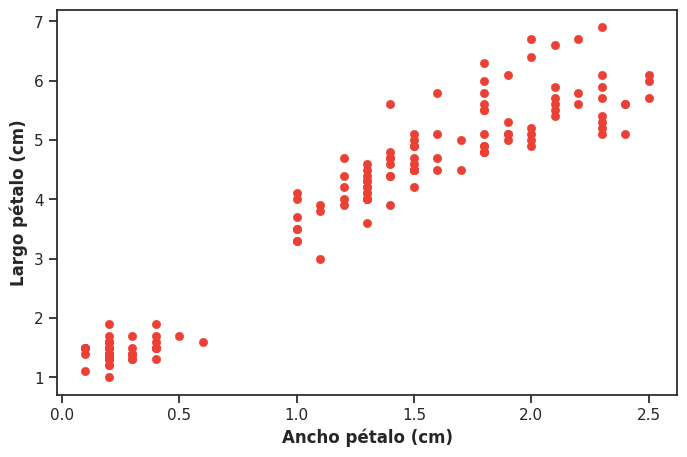

In [10]:
plt.figure(figsize = (8,5))

sns.scatterplot(x = 'petal_width_cm', y = 'petal_length_cm', s = 35, 
                color = '#eb4034', edgecolor = '#eb4034', 
                data = df)

plt.xlabel('Ancho pétalo (cm)', fontweight = 'bold')
plt.ylabel('Largo pétalo (cm)', fontweight = 'bold')

plt.show()

In [ ]:
# Observamos que la relación entre las dos variables cantitativas 
# continua es lineal positiva. Por este mortivo, usamos el coeficiente
# de Pearson

df[['petal_width_cm','petal_length_cm']].corr(method = 'pearson')

# Observamos una fuerte relación lineal.

,petal_width_cm,petal_length_cm
petal_width_cm,1.000000,0.962757
petal_length_cm,0.962757,1.000000
